In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**Giai đoạn 5**
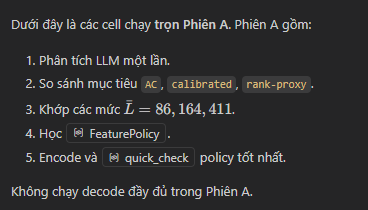

In [2]:
#Cell A1: Import và kiểm tra file
import sys
import importlib
import time
import json
import numpy as np
import torch

sys.path.insert(0, "/kaggle/working/FineZip28/update")

import adaptive_context_finezip_v3 as fz
import stage5_tools as st

importlib.reload(fz)
importlib.reload(st)

print("fz:", fz.__file__)
print("stage5_tools:", st.__file__)
print("codec version:", fz.FILE_VERSION)

assert fz.FILE_VERSION == 3

fz: /kaggle/working/FineZip28/update/adaptive_context_finezip_v3.py
stage5_tools: /kaggle/working/FineZip28/update/stage5_tools.py
codec version: 3


In [4]:
#Nếu biến chưa tồn tại, chạy:
from transformers import AutoTokenizer

data_path = (
    "/kaggle/working/FineZip28/"
    "notebook/finezip_experiment3.5/data/baseline_1mb.txt"
)

text = open(data_path, encoding="utf-8").read()

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.model_max_length = 10**9

tokens = np.asarray(
    tokenizer(text)["input_ids"],
    dtype=np.int64,
)

lm = fz.HFLM(
    "gpt2",
    device="cuda",
    max_batch_tokens=1024,
)

lm.eps = None

print({
    "tokens": len(tokens),
    "text_bytes": len(text.encode("utf-8")),
    "model_vocab": lm.V,
    "bos": lm.bos,
    "gpu": torch.cuda.get_device_name(0),
})

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

{'tokens': 286273, 'text_bytes': 1000000, 'model_vocab': 50257, 'bos': 50256, 'gpu': 'Tesla T4'}


In [5]:
#Cell A2: Kiểm tra dữ liệu và model
print({
    "tokens": len(tokens),
    "text_bytes": len(text.encode("utf-8")),
    "model_vocab": lm.V,
    "bos": lm.bos,
    "gpu": torch.cuda.get_device_name(0),
})

{'tokens': 286273, 'text_bytes': 1000000, 'model_vocab': 50257, 'bos': 50256, 'gpu': 'Tesla T4'}


In [6]:
#Cell A3: Chấm điểm 5 mức context một lần
padded = fz.pad_tokens(tokens, lm.bos)

start = time.perf_counter()

A = st.analyze(
    padded,
    lm,
    batch=8,
)

torch.cuda.synchronize()
analysis_seconds = time.perf_counter() - start

print("analysis_seconds:", analysis_seconds)

for L in fz.CTX_SIZES:
    print(
        L,
        "chunks =", len(A[L]["bits"]),
        "bits =", A[L]["bits"].shape,
        "ranks =", A[L]["ranks"].shape,
    )

analysis_seconds: 148.65206369500004
32 chunks = 8947 bits = (8947,) ranks = (8947, 32)
64 chunks = 4473 bits = (4473,) ranks = (4473, 64)
128 chunks = 2236 bits = (2236,) ranks = (2236, 128)
256 chunks = 1118 bits = (1118,) ranks = (1118, 256)
512 chunks = 559 bits = (559,) ranks = (559, 512)


In [7]:
#Lưu lại ngay để nếu notebook gián đoạn không phải chấm điểm lại:
np.savez_compressed(
    "/kaggle/working/stage5_analysis_A.npz",
    **{
        f"bits_{L}": A[L]["bits"]
        for L in fz.CTX_SIZES
    },
    **{
        f"ranks_{L}": A[L]["ranks"]
        for L in fz.CTX_SIZES
    },
)

print("Saved stage5_analysis_A.npz")

Saved stage5_analysis_A.npz


In [8]:
#Cell A4: Tạo ba mục tiêu DP
fixed_bytes = {
    32: 300576,
    64: 271704,
    128: 246976,
    256: 228006,
    512: 213691,
}

fixed_header = {
    32: 1194,
    64: 1194,
    128: 635,
    256: 355,
    512: 215,
}

kap = st.kappa(
    A,
    fixed_bytes,
    fixed_header,
)

print("kappa:")
for L in fz.CTX_SIZES:
    print(L, float(kap[L]))

costs = {
    "AC": st.cost_ac(A),
    "calibrated": st.cost_calibrated(A, kap),
    "rank-proxy": st.cost_rank_proxy(A),
}

print("cost objectives:", list(costs))

kappa:
32 1.2499349117279053
64 1.3009164333343506
128 1.3309227228164673
256 1.3549165725708008
512 1.3696880340576172
cost objectives: ['AC', 'calibrated', 'rank-proxy']


In [12]:
#Cell A5: Hàm encode đo chung
def measure_stage5_policy(policy, name, batch=8):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    start = time.perf_counter()

    blob, leaves = fz.encode(
        tokens,
        lm,
        policy,
        batch=batch,
    )

    torch.cuda.synchronize()
    encode_seconds = time.perf_counter() - start

    quick_ok = fz.quick_check(
        blob,
        lm,
        tokens,
        groups_per_L=3,
    )

    counts = {
        L: sum(length == L for _, length in leaves)
        for L in fz.CTX_SIZES
    }

    result = {
        "name": name,
        "compressed_bytes": len(blob),
        "ratio": len(text.encode("utf-8")) / len(blob),
        "encode_seconds": encode_seconds,
        "quick_check": bool(quick_ok),
        "chunk_counts": counts,
        "lbar": st.lbar(leaves),
        "decode_cost_sum_nL2": sum(
            L * L
            for _, L in leaves
        ),
        "encode_stats": fz.encode.last_stats.copy(),
        "blob_info": fz.inspect_blob(blob),
    }

    print(json.dumps(result, indent=2, default=str))
    return result, blob, leaves

In [13]:
# Cell A6: Chẩn đoán giả thuyết 1 ở cùng 𝐿ˉ
# Phần lam_for_Lbar chạy trên CPU, nên không cần gọi model thêm.
fixed_pts = [
    (32.0, 300576),
    (63.996, 271704),
    (127.975, 246976),
    (255.932, 228006),
    (511.846, 213691),
]

targets = [86, 164, 411]

pareto_points = []
pareto_runs = {}
pareto_blobs = {}
pareto_leaves = {}

for objective_name, cost in costs.items():
    for target in targets:
        lam, achieved_lbar = st.lam_for_Lbar(
            cost,
            len(padded),
            target,
        )

        print(
            f"\n===== {objective_name}, target Lbar={target}, "
            f"lambda={lam:.6g}, achieved={achieved_lbar:.3f} ====="
        )

        result, blob, leaves = measure_stage5_policy(
            st.TreeDP(cost, lam),
            f"{objective_name}-Lbar-{target}",
            batch=8,
        )

        key = (objective_name, target)

        result["target_lbar"] = target
        result["matched_lambda"] = lam
        result["achieved_lbar_cpu"] = achieved_lbar

        pareto_runs[key] = result
        pareto_blobs[key] = blob
        pareto_leaves[key] = leaves

        pareto_points.append((
            f"{objective_name} Lbar~{target}",
            st.lbar(leaves),
            result["compressed_bytes"],
        ))

        print(
            "matched:",
            {
                "objective": objective_name,
                "target_lbar": target,
                "lambda": lam,
                "actual_lbar": st.lbar(leaves),
                "bytes": result["compressed_bytes"],
            },
        )


===== AC, target Lbar=86, lambda=101.551, achieved=85.993 =====
quick_check: OK
{
  "name": "AC-Lbar-86",
  "compressed_bytes": 258158,
  "ratio": 3.873596789562981,
  "encode_seconds": 37.05846651000002,
  "quick_check": true,
  "chunk_counts": {
    "32": 563,
    "64": 2698,
    "128": 701,
    "256": 23,
    "512": 0
  },
  "lbar": 85.99262322566223,
  "decode_cost_sum_nL2": 24620032,
  "encode_stats": {
    "escapes": 0,
    "escape_pct": 0.0,
    "esc_bytes": 0,
    "total_bytes": 258158,
    "header_bytes": 1001,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "eps": 0.0
  },
  "blob_info": {
    "version": 3,
    "n_tokens": 286273,
    "eps": 0.0,
    "n_escapes": 0,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "chunk_counts": {
      "32": 563,
      "64": 2698,
      "128": 701,
      "256": 23,
      "512": 0
    },
    "env": {
      "cuda": "12.8",
 

In [14]:
#in báo cáo
st.report(
    pareto_points,
    fixed_pts,
)

policy                          L̄     bytes   Δ% bậc2  Δ% share
AC Lbar~86                    86.0    258158     -0.96     -1.92
AC Lbar~164                  164.0    238180     -0.56     -1.43
AC Lbar~411                  410.8    216534     -0.55     -1.28
calibrated Lbar~86            86.0    259387     -0.49     -1.45
calibrated Lbar~164          164.0    239271     -0.11     -0.98
calibrated Lbar~411          411.2    216684     -0.47     -1.20
rank-proxy Lbar~86            86.0    257584     -1.18     -2.13
rank-proxy Lbar~164          164.0    237893     -0.68     -1.55
rank-proxy Lbar~411          411.1    216280     -0.66     -1.39


In [15]:
#Cell A7: Học FeaturePolicy với train/test split
feature_results = {}
feature_models = {}

lam_feature, achieved = st.lam_for_Lbar(
    costs["AC"],
    len(padded),
    164,
)

C = st.block_cost_matrix(
    costs["AC"],
    lam_feature,
)

nb = len(C)
train_end = nb // 2

print({
    "blocks": nb,
    "train_blocks": train_end,
    "test_blocks": nb - train_end,
    "lambda": lam_feature,
    "target_lbar": 164,
    "achieved_lbar": achieved,
})

{'blocks': 559, 'train_blocks': 279, 'test_blocks': 280, 'lambda': 42.32646760475986, 'target_lbar': 164, 'achieved_lbar': 164.03442494690958}


In [16]:
for feature_name in ("entropy", "repeat", "llm32"):
    print(f"\n===== Feature: {feature_name} =====")

    bits32 = (
        A[32]["bits"]
        if feature_name == "llm32"
        else None
    )

    features = st.block_features(
        padded,
        feature_name,
        bits32,
    )[:nb]

    cuts, labels = st.fit_cuts(
        features[:train_end],
        C[:train_end],
        max_seg=4,
    )

    evaluation = st.eval_cuts(
        features[train_end:],
        C[train_end:],
        cuts,
        labels,
    )

    feature_results[feature_name] = {
        "cuts": cuts.tolist(),
        "labels": labels,
        "evaluation": evaluation,
    }

    feature_models[feature_name] = (
        cuts,
        labels,
    )

    print({
        "feature": feature_name,
        "cuts": np.round(cuts, 4).tolist(),
        "labels": labels,
        "test": evaluation,
    })


===== Feature: entropy =====
{'feature': 'entropy', 'cuts': [6.0358, 6.0618, 6.2783], 'labels': [256, 128, 256, 128], 'test': {'J_policy': np.float64(827606.3891601562), 'J_oracle_block': np.float64(824359.7639160156), 'J_best_fixed': np.float64(835174.7062988281), 'gain_captured': np.float64(0.6998018917511498)}}

===== Feature: repeat =====
{'feature': 'repeat', 'cuts': [0.4129, 0.7456], 'labels': [128, 256, 512], 'test': {'J_policy': np.float64(826727.2309570312), 'J_oracle_block': np.float64(824359.7639160156), 'J_best_fixed': np.float64(835174.7062988281), 'gain_captured': np.float64(0.7810929584998909)}}

===== Feature: llm32 =====
{'feature': 'llm32', 'cuts': [6.0159, 7.2761], 'labels': [256, 128, 256], 'test': {'J_policy': np.float64(831261.6220703125), 'J_oracle_block': np.float64(824359.7639160156), 'J_best_fixed': np.float64(835174.7062988281), 'gain_captured': np.float64(0.36182201347040377)}}


In [17]:
#Chọn feature theo gain_captured:
best_feature = max(
    feature_results,
    key=lambda name: feature_results[name]["evaluation"]["gain_captured"],
)

print("Best feature:", best_feature)
print(
    "gain_captured:",
    feature_results[best_feature]["evaluation"]["gain_captured"],
)

Best feature: repeat
gain_captured: 0.7810929584998909


In [18]:
#Cell A8: Encode FeaturePolicy tốt nhất
best_cuts, best_labels = feature_models[best_feature]

threshold_policy = st.ThresholdPolicy(
    best_feature,
    best_cuts,
    best_labels,
)

feature_result, feature_blob, feature_leaves = measure_stage5_policy(
    threshold_policy,
    f"ThresholdPolicy-{best_feature}",
    batch=8,
)

print({
    "feature": best_feature,
    "cuts": best_cuts.tolist(),
    "labels": best_labels,
    "lbar": st.lbar(feature_leaves),
    "bytes": feature_result["compressed_bytes"],
    "ratio": feature_result["ratio"],
    "quick_check": feature_result["quick_check"],
})

quick_check: OK
{
  "name": "ThresholdPolicy-repeat",
  "compressed_bytes": 239411,
  "ratio": 4.1769175184097636,
  "encode_seconds": 34.19703702100014,
  "quick_check": true,
  "chunk_counts": {
    "32": 1,
    "64": 1,
    "128": 1680,
    "256": 254,
    "512": 12
  },
  "lbar": 165.28624119816698,
  "decode_cost_sum_nL2": 47322112,
  "encode_stats": {
    "escapes": 0,
    "escape_pct": 0.0,
    "esc_bytes": 0,
    "total_bytes": 239411,
    "header_bytes": 562,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "eps": 0.0
  },
  "blob_info": {
    "version": 3,
    "n_tokens": 286273,
    "eps": 0.0,
    "n_escapes": 0,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "chunk_counts": {
      "32": 1,
      "64": 1,
      "128": 1680,
      "256": 254,
      "512": 12
    },
    "env": {
      "cuda": "12.8",
      "gpu": "Tesla T4",
      "matmul_precision": "highe

In [19]:
#Cell A9: Lưu toàn bộ kết quả Phiên A
stage5_session_A = {
    "analysis_seconds": analysis_seconds,
    "kappa": {
        str(L): float(kap[L])
        for L in fz.CTX_SIZES
    },
    "fixed_reference": fixed_pts,
    "pareto_runs": {
        f"{objective}_{target}": result
        for (objective, target), result in pareto_runs.items()
    },
    "pareto_points": [
        {
            "name": name,
            "lbar": float(lbar_value),
            "bytes": int(byte_count),
        }
        for name, lbar_value, byte_count in pareto_points
    ],
    "feature_results": feature_results,
    "best_feature": best_feature,
    "feature_policy": feature_result,
}

with open(
    "/kaggle/working/stage5_session_A.json",
    "w",
) as f:
    json.dump(
        stage5_session_A,
        f,
        indent=2,
        default=str,
    )

print("Saved /kaggle/working/stage5_session_A.json")

Saved /kaggle/working/stage5_session_A.json


**Kiểm chứng 2 giả thuyết cho việc Adaptive chưa thắng:**

In [2]:
import sys
import time
import json
import bz2
import struct
import numpy as np
import torch

sys.path.insert(0, "/kaggle/working/FineZip28/update")

import adaptive_context_finezip_v3 as fz

In [3]:
#Kiểm tra đúng codec
print("Loaded:", fz.__file__)
print("FILE_VERSION:", fz.FILE_VERSION)
print("Has DPPolicy:", hasattr(fz, "DPPolicy"))
print("Has FixedPolicy:", hasattr(fz, "FixedPolicy"))
print("Has inspect_blob:", hasattr(fz, "inspect_blob"))

assert fz.FILE_VERSION == 3

Loaded: /kaggle/working/FineZip28/update/adaptive_context_finezip_v3.py
FILE_VERSION: 3
Has DPPolicy: True
Has FixedPolicy: True
Has inspect_blob: True


In [4]:
#Đọc và tokenize dữ liệu
from transformers import AutoTokenizer

data_path = (
    "/kaggle/working/FineZip28/"
    "notebook/finezip_experiment3.5/data/baseline_1mb.txt"
)

text = open(data_path, encoding="utf-8").read()

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.model_max_length = 10**9

tokens = np.asarray(
    tokenizer(text)["input_ids"],
    dtype=np.int64,
)

print({
    "text_bytes": len(text.encode("utf-8")),
    "tokens": len(tokens),
})

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'text_bytes': 1000000, 'tokens': 286273}


In [5]:
#Load GPT-2 đúng môi trường
lm = fz.HFLM(
    "gpt2",
    device="cuda",
    max_batch_tokens=1024,
)

lm.eps = None

print({
    "bos": lm.bos,
    "vocab_size": lm.V,
    "max_batch_tokens": lm.max_batch_tokens,
    "gpu": torch.cuda.get_device_name(0),
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
})

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

{'bos': 50256, 'vocab_size': 50257, 'max_batch_tokens': 1024, 'gpu': 'Tesla T4', 'torch': '2.10.0+cu128', 'cuda': '12.8'}


In [6]:
#Hàm đo chung
def measure_encode(policy, name, batch=8):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    start = time.perf_counter()

    blob, leaves = fz.encode(
        tokens,
        lm,
        policy,
        batch=batch,
    )

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    info = fz.inspect_blob(blob)
    quick_ok = fz.quick_check(
        blob,
        lm,
        tokens,
        groups_per_L=3,
    )

    counts = {
        L: sum(length == L for _, length in leaves)
        for L in [32, 64, 128, 256, 512]
    }

    result = {
        "name": name,
        "compressed_bytes": len(blob),
        "ratio": len(text.encode("utf-8")) / len(blob),
        "encode_seconds": elapsed,
        "quick_check": bool(quick_ok),
        "counts": counts,
        "encode_stats": fz.encode.last_stats.copy(),
        "blob_info": info,
    }

    print(json.dumps(result, indent=2, default=str))
    return result, blob, leaves

In [7]:
#Cell 6: Chạy Adaptive-DP để có baseline trực tiếp (Chạy các lambda đại diện:)
adaptive_runs = {}
adaptive_blobs = {}
adaptive_leaves = {}
adaptive_policies = {}

for lam in [1000, 5000, 12000, 40000]:
    print(f"\n===== Adaptive-DP lambda={lam} =====")

    policy = fz.DPPolicy(lam=lam)
    result, blob, leaves = measure_encode(
        policy,
        f"Adaptive-DP-{lam}",
        batch=8,
    )

    adaptive_runs[lam] = result
    adaptive_blobs[lam] = blob
    adaptive_leaves[lam] = leaves
    adaptive_policies[lam] = policy


===== Adaptive-DP lambda=1000 =====
quick_check: OK
{
  "name": "Adaptive-DP-1000",
  "compressed_bytes": 216534,
  "ratio": 4.6182123823510395,
  "encode_seconds": 160.46178187199996,
  "quick_check": true,
  "counts": {
    "32": 1,
    "64": 17,
    "128": 50,
    "256": 397,
    "512": 346
  },
  "encode_stats": {
    "escapes": 0,
    "escape_pct": 0.0,
    "esc_bytes": 0,
    "total_bytes": 216534,
    "header_bytes": 278,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "eps": 0.0
  },
  "blob_info": {
    "version": 3,
    "n_tokens": 286273,
    "eps": 0.0,
    "n_escapes": 0,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "chunk_counts": {
      "32": 1,
      "64": 17,
      "128": 50,
      "256": 397,
      "512": 346
    },
    "env": {
      "cuda": "12.8",
      "gpu": "Tesla T4",
      "matmul_precision": "highest",
      "tf32": false,
      "torch"

In [8]:
#Cell 7: Chạy Fixed bằng chính codec v3(Đây là phép kiểm chứng quan trọng nhất cho giả thuyết thứ nhất:)
fixed_runs = {}
fixed_blobs = {}
fixed_leaves = {}

for L in [32, 64, 128, 256, 512]:
    print(f"\n===== Fixed-{L} =====")

    policy = fz.FixedPolicy(L)

    result, blob, leaves = measure_encode(
        policy,
        f"Fixed-{L}",
        batch=8,
    )

    fixed_runs[L] = result
    fixed_blobs[L] = blob
    fixed_leaves[L] = leaves


===== Fixed-32 =====
quick_check: OK
{
  "name": "Fixed-32",
  "compressed_bytes": 300576,
  "ratio": 3.326945597785585,
  "encode_seconds": 27.989155769000263,
  "quick_check": true,
  "counts": {
    "32": 8947,
    "64": 0,
    "128": 0,
    "256": 0,
    "512": 0
  },
  "encode_stats": {
    "escapes": 0,
    "escape_pct": 0.0,
    "esc_bytes": 0,
    "total_bytes": 300576,
    "header_bytes": 1194,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "eps": 0.0
  },
  "blob_info": {
    "version": 3,
    "n_tokens": 286273,
    "eps": 0.0,
    "n_escapes": 0,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "chunk_counts": {
      "32": 8947,
      "64": 0,
      "128": 0,
      "256": 0,
      "512": 0
    },
    "env": {
      "cuda": "12.8",
      "gpu": "Tesla T4",
      "matmul_precision": "highest",
      "tf32": false,
      "torch": "2.10.0+cu128"
    },
    "

In [11]:
#Cell 8: So sánh Adaptive và Fixed cùng codec
def mean_chunk_length_squared(leaves):
    total_tokens = sum(L for _, L in leaves)
    total_l2 = sum(L * L for _, L in leaves)
    return total_l2 / total_tokens


comparison = []

for L, result in fixed_runs.items():
    comparison.append({
        "policy": f"Fixed-{L}",
        "bytes": result["compressed_bytes"],
        "ratio": result["ratio"],
        "decode_cost_sum_nL2": sum(
            length * length
            for _, length in fixed_leaves[L]
        ),
        "effective_L": mean_chunk_length_squared(fixed_leaves[L]),
    })

for lam, result in adaptive_runs.items():
    comparison.append({
        "policy": f"Adaptive-DP-{lam}",
        "bytes": result["compressed_bytes"],
        "ratio": result["ratio"],
        "decode_cost_sum_nL2": sum(
            length * length
            for _, length in adaptive_leaves[lam]
        ),
        "effective_L": mean_chunk_length_squared(adaptive_leaves[lam]),
    })

for row in comparison:
    print(row)

{'policy': 'Fixed-32', 'bytes': 300576, 'ratio': 3.326945597785585, 'decode_cost_sum_nL2': 9161728, 'effective_L': 32.0}
{'policy': 'Fixed-64', 'bytes': 271704, 'ratio': 3.680475811912964, 'decode_cost_sum_nL2': 18322432, 'effective_L': 63.99642338213926}
{'policy': 'Fixed-128', 'bytes': 246976, 'ratio': 4.048976418761337, 'decode_cost_sum_nL2': 36639744, 'effective_L': 127.97496367497486}
{'policy': 'Fixed-256', 'bytes': 228006, 'ratio': 4.385849495188723, 'decode_cost_sum_nL2': 73274368, 'effective_L': 255.93204426064602}
{'policy': 'Fixed-512', 'bytes': 213691, 'ratio': 4.679654267142744, 'decode_cost_sum_nL2': 146543616, 'effective_L': 511.8462054319884}
{'policy': 'Adaptive-DP-1000', 'bytes': 216534, 'ratio': 4.6182123823510395, 'decode_cost_sum_nL2': 117609472, 'effective_L': 410.78529115904774}
{'policy': 'Adaptive-DP-5000', 'bytes': 238128, 'ratio': 4.199422159510851, 'decode_cost_sum_nL2': 47094784, 'effective_L': 164.49223203308372}
{'policy': 'Adaptive-DP-12000', 'bytes': 25

In [14]:
#Cell 9: Kiểm chứng giả thuyết DP đang tối ưu sai objective
import bz2
import numpy as np

def selected_arithmetic_bits(policy, leaves):
    bits_by_level = policy._bits
    total_bits = 0.0

    for start, L in leaves:
        index = start // L
        total_bits += float(bits_by_level[L][index])

    return total_bits


def raw_rank_bytes(blob, lm):
    parsed = fz._parse(blob, lm)

    n, n_pad, leaves, rank_by_start, escapes, batch_plan = parsed

    rank_width = 2 if lm.V <= np.iinfo(np.uint16).max + 1 else 4
    rank_dtype = "<u2" if rank_width == 2 else "<u4"

    rank_arrays = [
        rank_by_start[start].astype(rank_dtype)
        for start, _ in leaves
    ]

    if rank_arrays:
        raw_ranks = np.concatenate(rank_arrays)
    else:
        raw_ranks = np.empty(0, dtype=rank_dtype)

    return raw_ranks.tobytes()


objective_rows = []

for lam, policy in adaptive_policies.items():
    leaves = adaptive_leaves[lam]
    blob = adaptive_blobs[lam]

    arithmetic_bits = selected_arithmetic_bits(
        policy,
        leaves,
    )

    raw_bytes = raw_rank_bytes(
        blob,
        lm,
    )

    compressed_rank_bytes = len(
        bz2.compress(raw_bytes, 9)
    )

    decode_cost = sum(
        L * L
        for _, L in leaves
    )

    objective_rows.append({
        "lambda": lam,
        "arithmetic_bits": arithmetic_bits,
        "arithmetic_bits_per_token": arithmetic_bits / len(tokens),
        "raw_rank_bytes": len(raw_bytes),
        "bzip2_rank_bytes": compressed_rank_bytes,
        "actual_file_bytes": len(blob),
        "decode_cost_sum_nL2": decode_cost,
        "encode_objective_cost": sum(
            fz.est_time(L)
            for _, L in leaves
        ),
    })

for row in objective_rows:
    print(row)

{'lambda': 1000, 'arithmetic_bits': 1260553.0832977295, 'arithmetic_bits_per_token': 4.4033250893298685, 'raw_rank_bytes': 572608, 'bzip2_rank_bytes': 216256, 'actual_file_bytes': 216534, 'decode_cost_sum_nL2': 117609472, 'encode_objective_cost': 153.32350916556865}
{'lambda': 5000, 'arithmetic_bits': 1407512.0090637207, 'arithmetic_bits_per_token': 4.916677468932525, 'raw_rank_bytes': 572608, 'bzip2_rank_bytes': 237526, 'actual_file_bytes': 238128, 'decode_cost_sum_nL2': 47094784, 'encode_objective_cost': 92.63592705496659}
{'lambda': 12000, 'arithmetic_bits': 1557720.5815505981, 'arithmetic_bits_per_token': 5.441381414071876, 'raw_rank_bytes': 572608, 'bzip2_rank_bytes': 257126, 'actual_file_bytes': 258127, 'decode_cost_sum_nL2': 24636416, 'encode_objective_cost': 73.30741421988013}
{'lambda': 40000, 'arithmetic_bits': 1803641.9051818848, 'arithmetic_bits_per_token': 6.300426184732353, 'raw_rank_bytes': 572608, 'bzip2_rank_bytes': 286819, 'actual_file_bytes': 288012, 'decode_cost_sum

In [16]:
# Cell tiếp theo: DP tối ưu chi phí decode
# Chạy cell này trong notebook, không cần sửa file gốc:
class DecodeCostDPPolicy:
    def __init__(
        self,
        lam=0.0,
        levels=fz.CTX_SIZES,
        decode_c=1.0,
    ):
        if lam < 0:
            raise ValueError("lam must be non-negative")
        if decode_c <= 0:
            raise ValueError("decode_c must be positive")

        self.lam = float(lam)
        self.levels = tuple(levels)
        self.decode_c = float(decode_c)
        self._bits = None
        self._cache_key = None

    def _level_bits(self, toks, lm, batch):
        key = (
            len(toks),
            fz.zlib.crc32(np.asarray(toks).tobytes()),
            id(lm),
            batch,
        )

        if self._bits is None or self._cache_key != key:
            self._bits = {}

            for L in self.levels:
                starts = list(range(0, len(toks) - L + 1, L))

                self._bits[L] = (
                    fz.run_score(toks, starts, L, lm, batch)[0]
                    if starts
                    else np.array([])
                )

            self._cache_key = key

        return self._bits

    def __call__(self, toks, lm, batch):
        n_pad = len(toks)
        bits = self._level_bits(toks, lm, batch)

        def objective(s, L):
            bit_cost = bits[L][s // L]
            decode_cost = self.decode_c * L * L
            return bit_cost + self.lam * decode_cost

        def solve(s, L):
            if s >= n_pad:
                return 0.0, []

            split = None

            if L > fz.MIN_L:
                left_cost, left_leaves = solve(s, L // 2)
                right_cost, right_leaves = solve(
                    s + L // 2,
                    L // 2,
                )

                split = (
                    left_cost + right_cost,
                    left_leaves + right_leaves,
                )

            if s + L <= n_pad and L in bits:
                leaf = (
                    objective(s, L),
                    [(s, L)],
                )

                if split is None or leaf[0] <= split[0]:
                    return leaf

            return split

        leaves = []

        for s in range(0, n_pad, fz.MAX_L):
            leaves.extend(
                solve(s, fz.MAX_L)[1]
            )

        return leaves

In [17]:
# Chọn hệ số decode
# Từ kết quả lambda=1000:
decode_c = 12000.909038617 / 117609472
print("decode_c:", decode_c)


decode_c: 0.0001020403274883931


In [18]:
#Chạy thí nghiệm:
decode_c = 12000.909038617 / 117609472

decode_dp_runs = {}
decode_dp_blobs = {}
decode_dp_leaves = {}

for lam in [100, 300, 1000, 3000, 10000]:
    print(f"\n===== Decode-cost DP lambda={lam} =====")

    policy = DecodeCostDPPolicy(
        lam=lam,
        decode_c=decode_c,
    )

    result, blob, leaves = measure_encode(
        policy,
        f"DecodeCost-DP-{lam}",
        batch=8,
    )

    result["decode_cost_sum_nL2"] = sum(
        L * L
        for _, L in leaves
    )

    result["effective_L"] = (
        result["decode_cost_sum_nL2"]
        / sum(L for _, L in leaves)
    )

    decode_dp_runs[lam] = result
    decode_dp_blobs[lam] = blob
    decode_dp_leaves[lam] = leaves

    print({
        "lambda": lam,
        "bytes": result["compressed_bytes"],
        "ratio": result["ratio"],
        "decode_cost_sum_nL2": result["decode_cost_sum_nL2"],
        "effective_L": result["effective_L"],
        "quick_check": result["quick_check"],
    })


===== Decode-cost DP lambda=100 =====
quick_check: OK
{
  "name": "DecodeCost-DP-100",
  "compressed_bytes": 257940,
  "ratio": 3.876870590059704,
  "encode_seconds": 164.2910151189999,
  "quick_check": true,
  "counts": {
    "32": 551,
    "64": 2662,
    "128": 718,
    "256": 25,
    "512": 0
  },
  "encode_stats": {
    "escapes": 0,
    "escape_pct": 0.0,
    "esc_bytes": 0,
    "total_bytes": 257940,
    "header_bytes": 995,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "eps": 0.0
  },
  "blob_info": {
    "version": 3,
    "n_tokens": 286273,
    "eps": 0.0,
    "n_escapes": 0,
    "batch_plan": {
      "32": 8,
      "64": 8,
      "128": 8,
      "256": 4,
      "512": 2
    },
    "chunk_counts": {
      "32": 551,
      "64": 2662,
      "128": 718,
      "256": 25,
      "512": 0
    },
    "env": {
      "cuda": "12.8",
      "gpu": "Tesla T4",
      "matmul_precision": "highest",
      "tf32": false,
      "t

In [19]:
#lưu kết quả DP mới:
stage5_decode_cost = {
    str(lam): {
        "compressed_bytes": result["compressed_bytes"],
        "ratio": result["ratio"],
        "encode_seconds": result["encode_seconds"],
        "quick_check": result["quick_check"],
        "counts": result["counts"],
        "decode_cost_sum_nL2": result["decode_cost_sum_nL2"],
        "effective_L": result["effective_L"],
    }
    for lam, result in decode_dp_runs.items()
}

with open("/kaggle/working/stage5_decode_cost.json", "w") as f:
    json.dump(stage5_decode_cost, f, indent=2)

print("Saved stage5_decode_cost.json")

Saved stage5_decode_cost.json


**Giai đoạn 4**

In [1]:
%cd /kaggle/working

!git clone https://github.com/ThaoTo2806/FineZip28.git
!pip install -q transformers accelerate sentencepiece
!nvidia-smi

/kaggle/working
Cloning into 'FineZip28'...
remote: Enumerating objects: 192, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 192 (delta 34), reused 94 (delta 18), pack-reused 75 (from 1)
Receiving objects: 100% (192/192), 81.73 MiB | 36.69 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Updating files: 100% (102/102), done.
Wed Oct  7 11:46:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|================

In [ ]:
#Xác nhận đúng file v2
import sys
import importlib
from pathlib import Path

root = Path("/kaggle/working/FineZip28")
file_path = root / "update" / "adaptive_context_finezip_v2.py"

print(file_path.exists(), file_path)

sys.path.insert(0, str(root / "update"))

import adaptive_context_finezip_v2 as ac
print("Loaded:", ac.__file__)
print("FILE_VERSION:", ac.FILE_VERSION)
print("calibrate_eps:", hasattr(ac, "calibrate_eps"))

In [ ]:
#Import các hàm v2:
from adaptive_context_finezip_v2 import (
    HFLM,
    DPPolicy,
    encode,
    decode,
    quick_check,
    calibrate_eps,
)

In [ ]:
#Đọc và tokenize dữ liệu
import time
import json
import numpy as np
import torch
from transformers import AutoTokenizer

data_path = (
    "/kaggle/working/FineZip28/"
    "notebook/finezip_experiment3.5/data/baseline_1mb.txt"
)

text = open(data_path, encoding="utf-8").read()

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.model_max_length = 10**9

tokens = np.asarray(
    tokenizer(text)["input_ids"],
    dtype=np.int64,
)

print("Characters:", len(text))
print("Tokens:", len(tokens))

In [ ]:
#Load GPT-2 và calibrate epsilon
lm = HFLM(
    "gpt2",
    device="cuda",
    max_batch_tokens=1024,
)

eps = calibrate_eps(
    lm,
    tokens,
    L=512,
    batches=(1, 2, 4),
    n_chunks=8,
    margin=10.0,
)

lm.eps = eps
print("Calibrated eps:", eps)

In [ ]:
#Encode Adaptive-DP
dp = DPPolicy(lam=1000)

start = time.perf_counter()

blob, leaves = encode(
    tokens,
    lm,
    dp,
    batch=8,
)

torch.cuda.synchronize()
encode_seconds = time.perf_counter() - start

print("Encode seconds:", encode_seconds)
print("Blob bytes:", len(blob))
print("Compression ratio:", len(text.encode("utf-8")) / len(blob))
print("Encode stats:", encode.last_stats) #encode.last_stats cho biết số token được lưu bằng escape.
#Escape tăng kích thước file nhưng giúp decoder lossless giữa các batch/GPU khác nhau.

print({
    L: sum(length == L for _, length in leaves)
    for L in [32, 64, 128, 256, 512]
})

In [ ]:
#chạy quick check
ok = quick_check(
    blob,
    lm,
    tokens,
    batch=8,
    groups_per_L=1,
)

print("Quick check:", ok)

In [ ]:
#Decode đầy đủ
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start = time.perf_counter()

rec = decode(
    blob,
    lm,
    batch=8,
)

torch.cuda.synchronize()
decode_seconds = time.perf_counter() - start
decode_peak_mib = torch.cuda.max_memory_allocated() / 1024**2

lossless = np.array_equal(rec, tokens)

print({
    "decode_seconds": decode_seconds,
    "decode_gpu_peak_mib": decode_peak_mib,
    "lossless": lossless,
})

In [ ]:
#Lưu kết quả ngay:
import json

result = {
    "policy": "Adaptive-DP-1000-v2",
    "compressed_bytes": len(blob),
    "compression_ratio": len(text.encode("utf-8")) / len(blob),
    "encode_seconds": encode_seconds,
    "decode_seconds": decode_seconds,
    "decode_gpu_peak_mib": decode_peak_mib,
    "lossless": bool(lossless),
    "eps": float(eps),
    "escape_stats": encode.last_stats,
    "chunk_counts": {
        str(L): sum(length == L for _, length in leaves)
        for L in [32, 64, 128, 256, 512]
    },
}

with open("/kaggle/working/adaptive_results_v2.json", "w") as f:
    json.dump(result, f, indent=2)

print(json.dumps(result, indent=2))

In [ ]:
#chẩn đoán nhiễu
import numpy as np

padded = fz.pad_tokens(tokens, lm.bos)
starts = [i * 512 for i in range(4)]

inp, _ = fz.make_batch(
    padded,
    starts,
    512,
    lm.bos,
)

L = lambda x: lm._logits(x).detach().cpu().numpy()

b2 = L(inp)
b1 = np.concatenate([
    L(inp[i:i + 1])
    for i in range(len(inp))
])

d = np.abs(b2 - b1)

print("B1 vs B2, max tất cả      :", d.max())
print("          max vị trí >= 1 :", d[:, 1:].max())
print("          vị trí 0        :", d[:, 0].max())
print("          p99.99 (>=1)    :", np.percentile(d[:, 1:], 99.99))

ph = inp.copy()
ph[:, 257:] = lm.bos

placeholder_delta = np.abs(
    L(ph)[:, 256] - b2[:, 256]
)

print(
    "placeholder vs thật @256  :",
    placeholder_delta.max(),
)

In [ ]:
eps = fz.calibrate_eps(
    lm,
    tokens,
    L=512,
    batches=(1, 2, 4),
    n_chunks=8,
    margin=10.0,
    percentile=99.99,
)

print("eps mới:", eps)

In [ ]:
#chạy quick check với eps mới
lm.eps = eps

dp = fz.DPPolicy(lam=1000)

blob, leaves = fz.encode(
    tokens,
    lm,
    dp,
    batch=8,
)

print(fz.encode.last_stats)

ok = fz.quick_check(
    blob,
    lm,
    tokens,
    batch=8,
    groups_per_L=3,
)

print("quick check:", ok)

In [ ]:
#chạy decode toàn bộ:
import time
import torch

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start = time.perf_counter()

rec = fz.decode(
    blob,
    lm,
    batch=8,
)

torch.cuda.synchronize()

decode_seconds = time.perf_counter() - start
decode_peak_mib = torch.cuda.max_memory_allocated() / 1024**2
lossless = np.array_equal(rec, tokens)

print({
    "decode_seconds": decode_seconds,
    "decode_gpu_peak_mib": decode_peak_mib,
    "lossless": bool(lossless),
})

In [ ]:
#Lưu kết quả ngay:
import json

result = {
    "policy": "Adaptive-DP-1000-v2",
    "compressed_bytes": len(blob),
    "compression_ratio": len(text.encode("utf-8")) / len(blob),
    "encode_seconds": encode_seconds,
    "decode_seconds": decode_seconds,
    "decode_gpu_peak_mib": decode_peak_mib,
    "lossless": bool(lossless),
    "eps": float(eps),
    "escape_stats": encode.last_stats,
    "chunk_counts": {
        str(L): sum(length == L for _, length in leaves)
        for L in [32, 64, 128, 256, 512]
    },
}

with open("/kaggle/working/adaptive_results_v2.1.json", "w") as f:
    json.dump(result, f, indent=2)

print(json.dumps(result, indent=2))

In [ ]:
lm = fz.HFLM(
    "gpt2",
    device="cuda",
    max_batch_tokens=1024,
)

lm.eps = None
dp = fz.DPPolicy(lam=1000)

blob, leaves = fz.encode(
    tokens,
    lm,
    dp,
    batch=8,
)

print(fz.encode.last_stats)
print(fz.inspect_blob(blob))

In [ ]:
ok = fz.quick_check(
    blob,
    lm,
    tokens,
    groups_per_L=3,
)

print("quick_check:", ok)

In [ ]:
#chạy decode đầy đủ:
import time
import torch
import numpy as np

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start = time.perf_counter()

rec = fz.decode(blob, lm)

torch.cuda.synchronize()

decode_seconds = time.perf_counter() - start
decode_peak_mib = torch.cuda.max_memory_allocated() / 1024**2
lossless = np.array_equal(rec, tokens)

print({
    "decode_seconds": decode_seconds,
    "decode_gpu_peak_mib": decode_peak_mib,
    "lossless": bool(lossless),
})

In [ ]:
import json

result = {
    "version": 3,
    "policy": "Adaptive-DP-1000",
    "original_bytes": len(text.encode("utf-8")),
    "compressed_bytes": len(blob),
    "compression_ratio": len(text.encode("utf-8")) / len(blob),
    "encode_seconds": None,
    "decode_seconds": decode_seconds,
    "decode_gpu_peak_mib": decode_peak_mib,
    "lossless": bool(lossless),
    "escape_stats": fz.encode.last_stats,
    "blob_info": fz.inspect_blob(blob),
}

with open("/kaggle/working/adaptive_results_v3_lambda1000.json", "w") as f:
    json.dump(result, f, indent=2, default=str)

print(json.dumps(result, indent=2, default=str))

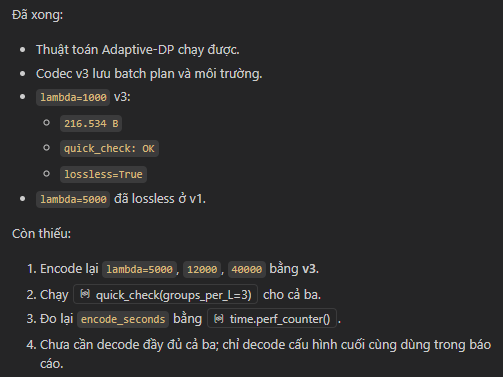

In [2]:
import sys
import time
import json
import numpy as np
import torch

sys.path.insert(0, "/kaggle/working/FineZip28/update")

import adaptive_context_finezip_v3 as fz

In [3]:
lm = fz.HFLM(
    "gpt2",
    device="cuda",
    max_batch_tokens=1024,
)

lm.eps = None

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [5]:
import numpy as np
from transformers import AutoTokenizer

data_path = (
    "/kaggle/working/FineZip28/"
    "notebook/finezip_experiment3.5/data/baseline_1mb.txt"
)

text = open(data_path, encoding="utf-8").read()

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.model_max_length = 10**9

tokens = np.asarray(
    tokenizer(text)["input_ids"],
    dtype=np.int64,
)

print("text bytes:", len(text.encode("utf-8")))
print("tokens:", len(tokens))

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

text bytes: 1000000
tokens: 286273


In [6]:
print("fz:", fz.__file__)
print("lm:", type(lm).__name__)
print("tokens:", tokens.shape)

fz: /kaggle/working/FineZip28/update/adaptive_context_finezip_v3.py
lm: HFLM
tokens: (286273,)


In [7]:
#Chạy ba lambda:
runs = {}

for lam in [5000, 12000, 40000]:
    print("Running lambda =", lam, flush=True)

    dp = fz.DPPolicy(lam=lam)

    torch.cuda.empty_cache()
    start = time.perf_counter()

    blob, leaves = fz.encode(
        tokens,
        lm,
        dp,
        batch=8,
    )

    torch.cuda.synchronize()
    encode_seconds = time.perf_counter() - start

    info = fz.inspect_blob(blob)
    quick_ok = fz.quick_check(
        blob,
        lm,
        tokens,
        groups_per_L=3,
    )

    runs[str(lam)] = {
        "compressed_bytes": len(blob),
        "ratio": len(text.encode("utf-8")) / len(blob),
        "encode_seconds": encode_seconds,
        "quick_check": bool(quick_ok),
        "encode_stats": fz.encode.last_stats,
        "blob_info": info,
    }

    print(runs[str(lam)], flush=True)

Running lambda = 5000
quick_check: OK
{'compressed_bytes': 238128, 'ratio': 4.199422159510851, 'encode_seconds': 195.814127761, 'quick_check': True, 'encode_stats': {'escapes': 0, 'escape_pct': 0.0, 'esc_bytes': 0, 'total_bytes': 238128, 'header_bytes': 602, 'batch_plan': {32: 8, 64: 8, 128: 8, 256: 4, 512: 2}, 'eps': 0.0}, 'blob_info': {'version': 3, 'n_tokens': 286273, 'eps': 0.0, 'n_escapes': 0, 'batch_plan': {32: 8, 64: 8, 128: 8, 256: 4, 512: 2}, 'chunk_counts': {32: 39, 64: 380, 128: 1401, 256: 292, 512: 13}, 'env': {'cuda': '12.8', 'gpu': 'Tesla T4', 'matmul_precision': 'highest', 'tf32': False, 'torch': '2.10.0+cu128'}, 'bytes': 238128}}
Running lambda = 12000
quick_check: OK
{'compressed_bytes': 258127, 'ratio': 3.8740619927400077, 'encode_seconds': 200.77724875700005, 'quick_check': True, 'encode_stats': {'escapes': 0, 'escape_pct': 0.0, 'esc_bytes': 0, 'total_bytes': 258127, 'header_bytes': 1001, 'batch_plan': {32: 8, 64: 8, 128: 8, 256: 4, 512: 2}, 'eps': 0.0}, 'blob_info':

In [20]:
#Encode lại lambda 1000 bằng v3:
import time
import torch
import numpy as np

dp_1000 = fz.DPPolicy(lam=1000)
lm.eps = None

torch.cuda.empty_cache()

start = time.perf_counter()

blob_1000, leaves_1000 = fz.encode(
    tokens,
    lm,
    dp_1000,
    batch=8,
)

torch.cuda.synchronize()
encode_seconds_1000 = time.perf_counter() - start

print("Encode seconds:", encode_seconds_1000)
print(fz.encode.last_stats)
print(fz.inspect_blob(blob_1000))

Encode seconds: 201.73223026399955
{'escapes': 0, 'escape_pct': 0.0, 'esc_bytes': 0, 'total_bytes': 216534, 'header_bytes': 278, 'batch_plan': {32: 8, 64: 8, 128: 8, 256: 4, 512: 2}, 'eps': 0.0}
{'version': 3, 'n_tokens': 286273, 'eps': 0.0, 'n_escapes': 0, 'batch_plan': {32: 8, 64: 8, 128: 8, 256: 4, 512: 2}, 'chunk_counts': {32: 1, 64: 17, 128: 50, 256: 397, 512: 346}, 'env': {'cuda': '12.8', 'gpu': 'Tesla T4', 'matmul_precision': 'highest', 'tf32': False, 'torch': '2.10.0+cu128'}, 'bytes': 216534}


In [21]:
#Kiểm tra nhanh trước khi decode:
quick_ok_1000 = fz.quick_check(
    blob_1000,
    lm,
    tokens,
    groups_per_L=3,
)

print("quick_check:", quick_ok_1000)

quick_check: OK
quick_check: True


In [22]:
#chọn lambda=1000 làm cấu hình cuối: (dùng đúng blob v3 của lambda=1000)
blob_final = blob_1000
final_lambda = 1000

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start = time.perf_counter()

rec = fz.decode(
    blob_final,
    lm,
)

torch.cuda.synchronize()

decode_seconds = time.perf_counter() - start
decode_peak_mib = torch.cuda.max_memory_allocated() / 1024**2
lossless = np.array_equal(rec, tokens)

print({
    "lambda": final_lambda,
    "compressed_bytes": len(blob_final),
    "decode_seconds": decode_seconds,
    "decode_peak_mib": decode_peak_mib,
    "lossless": bool(lossless),
})

{'lambda': 1000, 'compressed_bytes': 216534, 'decode_seconds': 12000.909038617, 'decode_peak_mib': 817.92919921875, 'lossless': True}


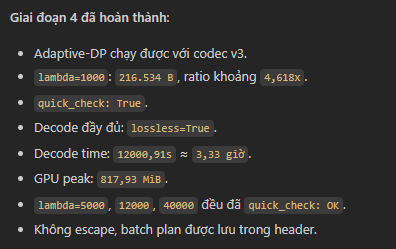

In [23]:
#Trước khi tắt session, lưu toàn bộ kết quả:

import json

results_final = {
    "1000": {
        "compressed_bytes": len(blob_1000),
        "ratio": len(text.encode("utf-8")) / len(blob_1000),
        "encode_seconds": encode_seconds_1000,
        "decode_seconds": decode_seconds,
        "decode_gpu_peak_mib": decode_peak_mib,
        "quick_check": bool(quick_ok_1000),
        "lossless": bool(lossless),
        "encode_stats": fz.encode.last_stats,
        "blob_info": fz.inspect_blob(blob_1000),
        "chunk_counts": {
            str(L): sum(length == L for _, length in leaves_1000)
            for L in [32, 64, 128, 256, 512]
        },
    },
    "5000": runs["5000"],
    "12000": runs["12000"],
    "40000": runs["40000"],
}

with open("/kaggle/working/adaptive_results_v3_final.json", "w") as f:
    json.dump(results_final, f, indent=2, default=str)

print(json.dumps(results_final, indent=2, default=str))

{
  "1000": {
    "compressed_bytes": 216534,
    "ratio": 4.6182123823510395,
    "encode_seconds": 201.73223026399955,
    "decode_seconds": 12000.909038617,
    "decode_gpu_peak_mib": 817.92919921875,
    "quick_check": true,
    "lossless": true,
    "encode_stats": {
      "escapes": 0,
      "escape_pct": 0.0,
      "esc_bytes": 0,
      "total_bytes": 216534,
      "header_bytes": 278,
      "batch_plan": {
        "32": 8,
        "64": 8,
        "128": 8,
        "256": 4,
        "512": 2
      },
      "eps": 0.0
    },
    "blob_info": {
      "version": 3,
      "n_tokens": 286273,
      "eps": 0.0,
      "n_escapes": 0,
      "batch_plan": {
        "32": 8,
        "64": 8,
        "128": 8,
        "256": 4,
        "512": 2
      },
      "chunk_counts": {
        "32": 1,
        "64": 17,
        "128": 50,
        "256": 397,
        "512": 346
      },
      "env": {
        "cuda": "12.8",
        "gpu": "Tesla T4",
        "matmul_precision": "highest",
        

In [24]:
#lưu cả file nén cuối:
with open("/kaggle/working/adaptive_lambda1000_v3.fzac", "wb") as f:
    f.write(blob_1000)

print("Saved:", len(blob_1000), "bytes")

Saved: 216534 bytes


🟢 NB01 — FineZip Setup & Dataset

In [ ]:
#Cell 1 — Kiểm tra GPU
!nvidia-smi

In [ ]:
#Cell 2 — Kiểm tra Python
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:",
          torch.cuda.get_device_properties(0).total_memory / 1024**3,
          "GB")

In [ ]:
#Cell 3 — Clone FineZip
%cd /kaggle/working

!git clone https://github.com/fazalmittu/finezip.git
%cd /kaggle/working/finezip

!ls -lah

In [ ]:
#Cell 4 — Kiểm tra repository
!find . -maxdepth 2 -type f | head -100

In [ ]:
#Cell 5 — Cài dependency
!pip install -q -r requirements.txt

In [ ]:
!ls

In [ ]:
!sed -n '1,240p' README.md

In [ ]:
!find . -maxdepth 2 -type f | sort

In [ ]:
!sed -n '1,260p' finezip/eval_clean.py

In [ ]:
import importlib.util

packages = [
    "numpy",
    "torch",
    "transformers",
    "bitsandbytes",
    "matplotlib",
    "tqdm"
]

for pkg in packages:
    print(f"{pkg:15} ->", "OK" if importlib.util.find_spec(pkg) else "MISSING")

In [ ]:
!pip install -q bitsandbytes

In [ ]:
#Cell 6 — Kiểm tra package
import torch
import transformers
import peft

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)

In [ ]:
#Cell 7 — Tạo thư mục experiment
from pathlib import Path

ROOT = Path("/kaggle/working/finezip_experiment")

for p in [
    "data",
    "compressed",
    "decompressed",
    "results",
    "logs"
]:
    (ROOT / p).mkdir(parents=True, exist_ok=True)

print(ROOT)

In [ ]:
#Cell 8 — Tạo text nhỏ để test
#Trước khi tải enwik8:
text = """
Machine learning is a method of data analysis.
Machine learning can learn patterns from data.
Deep learning is a branch of machine learning.
Neural networks are widely used in machine learning.
""" * 5000

input_file = ROOT / "data" / "test_small.txt"

input_file.write_text(text)

print("File size:",
      input_file.stat().st_size / 1024**2,
      "MB")

In [ ]:
#Cell 9 — Tạo 1 MB dataset
target_size = 1 * 1024 * 1024

base_text = """
Machine learning is a method of data analysis.
Deep learning uses neural networks.
Large language models can predict the next token.
Text compression removes statistical redundancy.
""" 

text = ""

while len(text.encode("utf-8")) < target_size:
    text += base_text

text = text.encode("utf-8")[:target_size].decode(
    "utf-8",
    errors="ignore"
)

one_mb = ROOT / "data" / "text_1mb.txt"
one_mb.write_text(text)

print("Size:",
      one_mb.stat().st_size / 1024**2,
      "MB")

In [ ]:
#Cell 10 — Checkpoint NB01
assert torch.cuda.is_available()
assert input_file.exists()
assert one_mb.exists()

print("NB01 CHECKPOINT: PASS")

🟢 NB02 — FineZip Reproduction

In [ ]:
#Cell 1 — Load configuration
#Đầu tiên xem README/code để biết command chính xác:
%cd /kaggle/working/finezip

!sed -n '1,300p' README.md

In [ ]:
!find . -maxdepth 3 -type f \
    \( -name "*.py" -o -name "*.sh" \) | sort

In [ ]:
# Cell 2 — Inspect FineZip main configuration

%cd /kaggle/working/finezip

!sed -n '250,440p' finezip/eval_clean.py

In [ ]:
# Cell 2 — Test GPT-2 model loading

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(model_name)

print("Model:", model_name)
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    model = model.to("cuda")
    print("Model device:", next(model.parameters()).device)

print("Tokenizer vocab size:", tokenizer.vocab_size)

In [ ]:
# Cell 2 — Test GPT-2 prediction

text = "The quick brown fox jumps over the"

inputs = tokenizer(text, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model(**inputs)

print("Input shape :", inputs["input_ids"].shape)
print("Logits shape:", outputs.logits.shape)

next_token_logits = outputs.logits[:, -1, :]
next_token = torch.argmax(next_token_logits, dim=-1)

print("Predicted token ID:", next_token.item())
print("Predicted token:", tokenizer.decode(next_token))

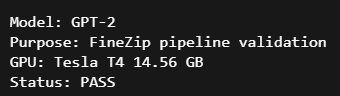

In [ ]:
#Cell 3 — Chuẩn bị file text nhỏ
from pathlib import Path

work_dir = Path("/kaggle/working/finezip_experiment")
data_dir = work_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)

text = """
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.
"""

input_file = data_dir / "text_test.txt"
input_file.write_text(text.strip() + "\n", encoding="utf-8")

print("Created:", input_file)
print("Size:", input_file.stat().st_size, "bytes")
print("Content:")
print(input_file.read_text(encoding="utf-8"))

In [ ]:
# Verify input file

!ls -lh /kaggle/working/finezip_experiment/data/text_test.txt
!cat /kaggle/working/finezip_experiment/data/text_test.txt


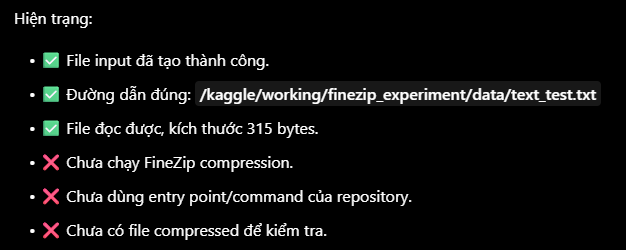

In [ ]:
# Cell 3 — Inspect FineZip compression entry point

%cd /kaggle/working/finezip

!sed -n '413,425p' finezip/eval_clean.py


In [ ]:
# Cell 3 — Prepare FineZip output directories

%cd /kaggle/working/finezip

!mkdir -p zipped
!mkdir -p /kaggle/working/finezip_experiment/results


 nhánh else load GPT-2 lên CPU, trong khi FineZip đưa token lên CUDA.
 Cụ thể hiện tại:

loaded_model = AutoModelForCausalLM.from_pretrained(model)

không có .to("cuda").

Sửa đoạn này

In [ ]:
# Fix GPT-2 device mismatch: move the loaded model to CUDA

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")
src = path.read_text()

old = '''                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model'''

new = '''                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_model = loaded_model.to("cuda")
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model'''

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Patch applied: GPT-2 will be loaded onto CUDA.")
else:
    print("Target code was not found. No changes made.")


In [ ]:
#Verify
%cd /kaggle/working/finezip

!sed -n '300,310p' finezip/eval_clean.py #Đoạn này xác nhận GPT-2 được chuyển sang CUDA:

In [ ]:
#Bước 1 — Reload module
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)

print("eval_clean reloaded")

In [ ]:
#Tạo thư mục plots
%cd /kaggle/working/finezip

!mkdir -p plots
!mkdir -p zipped

print("plots/ and zipped/ are ready.")


In [ ]:
# Bước 2 — Chạy lại compression
# Cell 3 — Run FineZip compression on the small test file

%cd /kaggle/working/finezip

eval_clean.memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=[32],
    batch_size=1,
    file_path="/kaggle/working/finezip_experiment/data/text_test.txt",
    save_name="gpt2_test"
)

In [ ]:
#Kiểm tra output compression
%cd /kaggle/working/finezip

!ls -lh zipped/
!ls -lh plots/


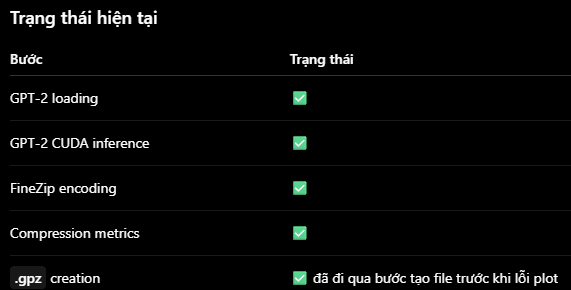

In [ ]:
# Cell 4 — Measure FineZip compression time

import time
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from finezip.eval_clean import ZipModel

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)

input_file = "/kaggle/working/finezip_experiment/data/text_test.txt"
output_file = "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"

start = time.perf_counter()

zip_model.zip_file(input_file, output_file)

if torch.cuda.is_available():
    torch.cuda.synchronize()

compress_time = time.perf_counter() - start

print("Compression time:", compress_time, "seconds")
print("Compressed file:", output_file)
print("Compressed size:", os.path.getsize(output_file), "bytes")


In [ ]:
# Inspect the exact FineZip zip/unzip implementation

%cd /kaggle/working/finezip

!sed -n '195,240p' finezip/eval_clean.py


In [ ]:
from pathlib import Path

p = Path("/kaggle/working/finezip_experiment/gpt2_32_1.gpz")

print("Exists:", p.exists())
print("Size:", p.stat().st_size if p.exists() else "N/A")

if p.exists():
    data = p.read_bytes()
    print("First 32 bytes:", data[:32])


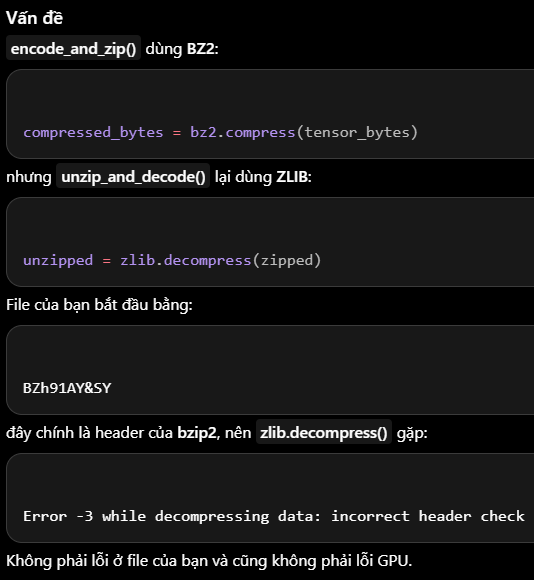

In [ ]:
# Fix FineZip decompression: use bz2 to match encode_and_zip()

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")
src = path.read_text()

old = "unzipped = zlib.decompress(zipped)"
new = "unzipped = bz2.decompress(zipped)"

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Fixed: zlib.decompress -> bz2.decompress")
else:
    print("Target line not found.")


In [ ]:
%cd /kaggle/working/finezip

!sed -n '210,220p' finezip/eval_clean.py


In [ ]:
#reload module:
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)


In [ ]:
#Quan trọng: zip_model hiện tại được tạo từ class trước khi reload, nên tạo lại ZipModel bằng class mới:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = eval_clean.ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)


là warning khi load GPT-2, không phải lỗi, và Cell 2 trước đó đã chạy inference thành công. đã tạo lại zip_model bằng class sau khi sửa bz2.decompress, nên chạy Cell 5:

In [ ]:
# Cell 5 — Decompression + lossless verification

import time
from pathlib import Path

input_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

decoded_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test_decoded.txt"
)

start = time.perf_counter()

zip_model.unzip_file(
    str(compressed_file),
    str(decoded_file)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompress_time = time.perf_counter() - start

print("Decompression time:", decompress_time, "seconds")
print("Decoded file:", decoded_file)
#Nếu chạy thành công, chưa kết luận lossless ngay. Sau đó chạy cell verify:

In [ ]:
# Verify lossless reconstruction

original_text = input_file.read_text(encoding="utf-8")
decoded_text = decoded_file.read_text(encoding="utf-8")

print("Original size :", len(original_text.encode("utf-8")), "bytes")
print("Decoded size  :", len(decoded_text.encode("utf-8")), "bytes")
print("Exact match   :", original_text == decoded_text)

if original_text == decoded_text:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text differs from original.")


In [ ]:
# Cell 6 — So sánh nội dung original và decoded

print("===== ORIGINAL =====")
print(original_text)

print("\n===== DECODED =====")
print(decoded_text)

print("\n===== repr ORIGINAL =====")
print(repr(original_text))

print("\n===== repr DECODED =====")
print(repr(decoded_text))


In [ ]:
# Find the first difference

from itertools import zip_longest

for i, (a, b) in enumerate(zip_longest(original_text, decoded_text, fillvalue="")):
    if a != b:
        print("First difference at character:", i)
        print("Original:", repr(a))
        print("Decoded :", repr(b))
        print("Original context:", repr(original_text[max(0, i-30):i+50]))
        print("Decoded context :", repr(decoded_text[max(0, i-30):i+50]))
        break
else:
    print("No character difference found.")


In [ ]:
#Bước tiếp theo: kiểm tra encode/decode trực tiếp. kiểm tra trước cả BZ2:
# Cell 7 — Test FineZip encode/decode directly

test_text = original_text

print("Original text:")
print(repr(test_text))

tokens = zip_model.text_to_tokens(test_text)

print("\nToken tensor:")
print("Shape:", tokens.shape)
print("Dtype:", tokens.dtype)
print("First tokens:", tokens.flatten()[:20].tolist())

encoded = zip_model.encode(test_text)

print("\nEncoded:")
print("Type:", type(encoded))
print("Length:", len(encoded))
print("First values:", encoded[:20])

decoded_direct = zip_model.decode(
    torch.tensor(encoded)
)

print("\nDirect decoded text:")
print(repr(decoded_direct))

print("\nDirect exact match:", test_text == decoded_direct)


In [ ]:
#Và kiểm tra dtype/giá trị trước khi BZ2
# Cell 8 — Inspect encode dtype and decode assumptions

encoded_tensor = torch.tensor(encoded)

print("Encoded tensor dtype:", encoded_tensor.dtype)
print("Encoded tensor shape:", encoded_tensor.shape)
print("Min:", encoded_tensor.min().item())
print("Max:", encoded_tensor.max().item())

print("\nDecoder reconstruction dtype:")
import array

arr = array.array("H", encoded_tensor.numpy().tobytes())

reconstructed = torch.tensor(arr)

print("Reconstructed dtype:", reconstructed.dtype)
print("Reconstructed shape:", reconstructed.shape)
print("Same length:", len(encoded_tensor) == len(reconstructed))
print("Same values:", torch.equal(encoded_tensor, reconstructed))


In [ ]:
# Cell 9 — Fix FineZip tensor serialization dtype

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")

src = path.read_text()

old = 'unzipped = array.array("H", unzipped)'
new = 'unzipped = array.array("i", unzipped)'

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Fixed tensor deserialization: uint16 -> int32")
else:
    print("Target line not found.")


In [ ]:
%cd /kaggle/working/finezip

!sed -n '210,220p' finezip/eval_clean.py

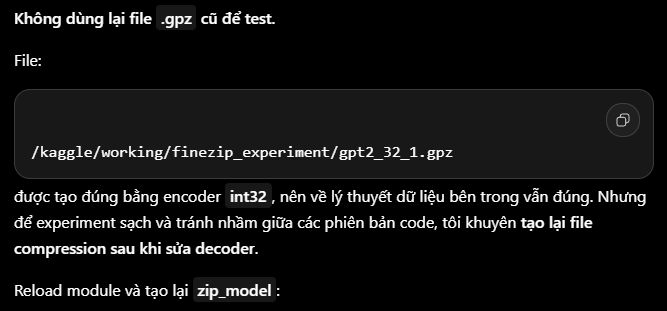

In [ ]:
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = eval_clean.ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)
#Sau đó tạo lại .gpz:

In [ ]:
# Re-create compressed file after fixing serialization

input_file = "/kaggle/working/finezip_experiment/data/text_test.txt"
compressed_file = "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"

zip_model.zip_file(
    input_file,
    compressed_file
)

print("Re-created:", compressed_file)


In [ ]:
#Sau đó chạy lại Cell 5
import time
from pathlib import Path

input_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

decoded_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test_decoded.txt"
)

start = time.perf_counter()

zip_model.unzip_file(
    str(compressed_file),
    str(decoded_file)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompress_time = time.perf_counter() - start

print("Decompression time:", decompress_time, "seconds")
print("Decoded file:", decoded_file)


In [ ]:
#verify:
original_text = input_file.read_text(encoding="utf-8")
decoded_text = decoded_file.read_text(encoding="utf-8")

print("Original size :", len(original_text.encode("utf-8")), "bytes")
print("Decoded size  :", len(decoded_text.encode("utf-8")), "bytes")
print("Exact match   :", original_text == decoded_text)

if original_text == decoded_text:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text differs from original.")


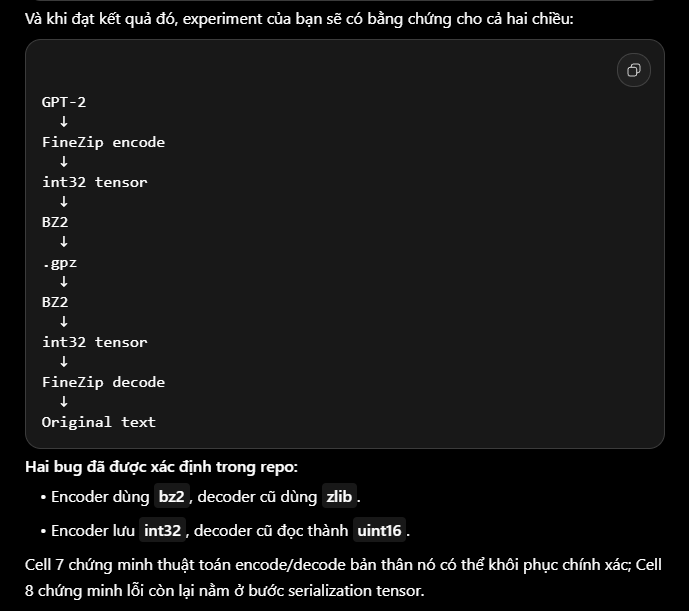

In [ ]:
# Cell 9 — Compression ratio

from pathlib import Path

original_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

original_size = original_file.stat().st_size
compressed_size = compressed_file.stat().st_size

compression_ratio = original_size / compressed_size
compressed_percent = compressed_size / original_size * 100
space_saved = (1 - compressed_size / original_size) * 100

print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", compression_ratio)
print("Compressed size % :", compressed_percent, "%")
print("Space saved       :", space_saved, "%")


**Nếu muốn đo peak memory của chính lần compression, nên reset trước khi compression:**

torch.cuda.reset_peak_memory_stats()

**rồi chạy compression, sau đó:**

torch.cuda.synchronize()

print(
    "Peak GPU memory:",
    torch.cuda.max_memory_allocated(0) / 1024**2,
    "MiB"
)

In [ ]:
# Cell 10 — GPU memory measurement

import torch

if torch.cuda.is_available():
    torch.cuda.synchronize()

    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved = torch.cuda.memory_reserved(0) / 1024**2
    max_allocated = torch.cuda.max_memory_allocated(0) / 1024**2
    max_reserved = torch.cuda.max_memory_reserved(0) / 1024**2

    print("GPU:", torch.cuda.get_device_name(0))
    print("Current allocated :", allocated, "MiB")
    print("Current reserved  :", reserved, "MiB")
    print("Peak allocated    :", max_allocated, "MiB")
    print("Peak reserved     :", max_reserved, "MiB")
else:
    print("CUDA is not available.")


In [ ]:
# Cell 11 — Save experiment log

import json
from pathlib import Path

log_dir = Path("/kaggle/working/finezip_experiment/logs")
log_dir.mkdir(parents=True, exist_ok=True)

log = {
    "model": "gpt2",
    "purpose": "FineZip pipeline validation",
    "context_size": 32,
    "batch_size": 1,

    "input_file": str(original_file),
    "compressed_file": str(compressed_file),
    "decoded_file": str(decoded_file),

    "original_size_bytes": original_size,
    "compressed_size_bytes": compressed_size,

    "compression_ratio": compression_ratio,

    "compression_time_seconds": 1.1746998789999452,
    "decompression_time_seconds": decompress_time,

    "lossless": original_text == decoded_text,

    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,

    "gpu_peak_memory_mib": (
        torch.cuda.max_memory_allocated(0) / 1024**2
        if torch.cuda.is_available()
        else None
    )
}

log_file = log_dir / "gpt2_test.json"

with open(log_file, "w", encoding="utf-8") as f:
    json.dump(log, f, indent=2)

print("Log saved:", log_file)


In [ ]:
!zip -r /kaggle/working/finezip_experiment.zip /kaggle/working/finezip_experiment

Giai đoạn 2

In [ ]:
#Cell 1 — Tạo baseline_1mb.txt đúng 1,000,000 bytes (Download đúng enwik8 và tạo 1 MB)
from pathlib import Path
import urllib.request

# ====== CONFIG ======
DATA_DIR = Path("/kaggle/working/finezip_experiment/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ENWIK8 = DATA_DIR / "enwik8"
DST = DATA_DIR / "baseline_1mb.txt"

TARGET_SIZE = 1_000_000

# ====== DOWNLOAD ENWIK8 ======
URL = "http://mattmahoney.net/dc/enwik8.zip"
ZIP_FILE = DATA_DIR / "enwik8.zip"

if not ENWIK8.exists():
    print("Downloading enwik8...")

    urllib.request.urlretrieve(URL, ZIP_FILE)

    print("Downloaded:", ZIP_FILE)
    print("Size:", ZIP_FILE.stat().st_size, "bytes")

    import zipfile

    with zipfile.ZipFile(ZIP_FILE, "r") as z:
        print("Files in archive:", z.namelist())
        z.extract("enwik8", DATA_DIR)

    print("Extracted:", ENWIK8)

else:
    print("enwik8 already exists:", ENWIK8)


# ====== VERIFY ENWIK8 ======
source_size = ENWIK8.stat().st_size

print("\nenwik8 size:", source_size, "bytes")

if source_size < TARGET_SIZE:
    raise ValueError(
        f"enwik8 chỉ có {source_size} bytes, "
        f"không đủ {TARGET_SIZE} bytes."
    )


# ====== CREATE EXACT 1 MB ======
data = ENWIK8.read_bytes()[:TARGET_SIZE]

DST.write_bytes(data)

print("\nCreated:", DST)
print("Size:", DST.stat().st_size, "bytes")

assert DST.stat().st_size == TARGET_SIZE

print("PASS — baseline_1mb.txt is exactly 1,000,000 bytes")


In [ ]:
import hashlib

data = DST.read_bytes()

sha256 = hashlib.sha256(data).hexdigest()

print("File:", DST)
print("Size:", len(data))
print("SHA256:", sha256)


In [ ]:
#Run gzip
import gzip
import time
from pathlib import Path

# ====== CONFIG ======
input_file = DST

gzip_file = BASELINE_DIR / "baseline_1mb.txt.gz"
gzip_decoded = BASELINE_DIR / "baseline_1mb_gzip_decoded.txt"

# ====== COMPRESSION ======
start = time.perf_counter()

with open(input_file, "rb") as f_in:
    with gzip.open(gzip_file, "wb", compresslevel=9) as f_out:
        while True:
            chunk = f_in.read(1024 * 1024)
            if not chunk:
                break
            f_out.write(chunk)

gzip_compression_time = time.perf_counter() - start

# ====== DECOMPRESSION ======
start = time.perf_counter()

with gzip.open(gzip_file, "rb") as f_in:
    with open(gzip_decoded, "wb") as f_out:
        while True:
            chunk = f_in.read(1024 * 1024)
            if not chunk:
                break
            f_out.write(chunk)

gzip_decompression_time = time.perf_counter() - start

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = gzip_decoded.read_bytes()

gzip_lossless = original == decoded

# ====== METRICS ======
original_size = len(original)
compressed_size = gzip_file.stat().st_size

gzip_ratio = original_size / compressed_size

print("========== GZIP ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", gzip_ratio)
print("Compression time  :", gzip_compression_time, "seconds")
print("Decompression time:", gzip_decompression_time, "seconds")
print("Decoded size      :", len(decoded), "bytes")
print("Exact match       :", gzip_lossless)

if gzip_lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


In [ ]:
#Run BZip2
import bz2
import time
from pathlib import Path

# ====== CONFIG ======
input_file = DST

bz2_file = BASELINE_DIR / "baseline_1mb.txt.bz2"
bz2_decoded = BASELINE_DIR / "baseline_1mb_bz2_decoded.txt"

# ====== COMPRESSION ======
start = time.perf_counter()

with open(input_file, "rb") as f_in:
    data = f_in.read()

compressed_data = bz2.compress(data, compresslevel=9)

with open(bz2_file, "wb") as f_out:
    f_out.write(compressed_data)

bz2_compression_time = time.perf_counter() - start

# ====== DECOMPRESSION ======
start = time.perf_counter()

with open(bz2_file, "rb") as f_in:
    compressed_data = f_in.read()

decoded_data = bz2.decompress(compressed_data)

with open(bz2_decoded, "wb") as f_out:
    f_out.write(decoded_data)

bz2_decompression_time = time.perf_counter() - start

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = bz2_decoded.read_bytes()

bz2_lossless = original == decoded

# ====== METRICS ======
original_size = len(original)
compressed_size = bz2_file.stat().st_size

bz2_ratio = original_size / compressed_size

print("========== BZIP2 ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", bz2_ratio)
print("Compression time  :", bz2_compression_time, "seconds")
print("Decompression time:", bz2_decompression_time, "seconds")
print("Decoded size      :", len(decoded), "bytes")
print("Exact match       :", bz2_lossless)

if bz2_lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


In [ ]:
#chạy FineZip GPT-2, context 32 trên 1 MB
import sys
import os
import time
import torch
from pathlib import Path

# ====== PATHS ======
FINEZIP_ROOT = Path("/kaggle/working/finezip")
INPUT_FILE = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

# FineZip outputs are relative to current working directory
(FINEZIP_ROOT / "zipped").mkdir(parents=True, exist_ok=True)
(FINEZIP_ROOT / "plots").mkdir(parents=True, exist_ok=True)

# ====== MOVE TO FINEZIP REPO ======
os.chdir(FINEZIP_ROOT)

# Make sure Python can import finezip/eval_clean.py
if str(FINEZIP_ROOT) not in sys.path:
    sys.path.insert(0, str(FINEZIP_ROOT))

from finezip.eval_clean import memory_eval

# ====== GPU RESET ======
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Allocated before:",
        f"{torch.cuda.memory_allocated() / 1024**2:.2f} MiB"
    )
    print(
        "Reserved before:",
        f"{torch.cuda.memory_reserved() / 1024**2:.2f} MiB"
    )

# ====== RUN FINEZIP ======
start = time.perf_counter()

memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=[32],
    batch_size=1,
    file_path=str(INPUT_FILE),
    save_name="baseline_gpt2_32_1mb"
)

total_time = time.perf_counter() - start

# ====== GPU MEMORY ======
if torch.cuda.is_available():
    torch.cuda.synchronize()

    peak_allocated = (
        torch.cuda.max_memory_allocated() / 1024**2
    )

    current_allocated = (
        torch.cuda.memory_allocated() / 1024**2
    )

    current_reserved = (
        torch.cuda.memory_reserved() / 1024**2
    )

    print("\n========== GPU MEMORY ==========")
    print(f"Peak allocated    : {peak_allocated:.2f} MiB")
    print(f"Current allocated : {current_allocated:.2f} MiB")
    print(f"Current reserved  : {current_reserved:.2f} MiB")

print("\nTotal FineZip runtime:", total_time, "seconds")


In [ ]:
#chạy Cell decompress + Exact Match
from pathlib import Path
import time

# ====== FILES ======
finezip_file = Path(
    "/kaggle/working/finezip/zipped/gpt2_32_1.gpz"
)

finezip_decoded = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb_finezip_decoded.txt"
)

input_file = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

print("FineZip file:", finezip_file)
print("Exists:", finezip_file.exists())

if not finezip_file.exists():
    raise FileNotFoundError(
        f"Không tìm thấy: {finezip_file}"
    )

# ====== IMPORT ZIPMODEL ======
from finezip.eval_clean import ZipModel
from transformers import AutoTokenizer, AutoModelForCausalLM

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading GPT-2...")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
model = model.to(device)
model.eval()

zip_model = ZipModel(
    model_name="gpt2",
    tokenizer_name="gpt2",
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)

# ====== DECOMPRESSION ======
print("\nStarting FineZip decompression...")

start = time.perf_counter()

zip_model.unzip_file(
    str(finezip_file),
    str(finezip_decoded)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompression_time = time.perf_counter() - start

print("Decompression time:", decompression_time, "seconds")

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = finezip_decoded.read_bytes()

print("\n========== FINEZIP VERIFY ==========")
print("Original size :", len(original), "bytes")
print("Decoded size  :", len(decoded), "bytes")
print("Exact match   :", original == decoded)

if original == decoded:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


In [ ]:
#compressed size + ratio
from pathlib import Path

finezip_file = Path(
    "/kaggle/working/finezip/zipped/gpt2_32_1.gpz"
)

original_size = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
).stat().st_size

compressed_size = finezip_file.stat().st_size

compression_ratio = original_size / compressed_size
compressed_percent = compressed_size / original_size * 100
space_saved = (1 - compressed_size / original_size) * 100

print("========== FINEZIP SIZE ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", compression_ratio)
print("Compressed %      :", compressed_percent, "%")
print("Space saved       :", space_saved, "%")

assert original_size == 1_000_000
assert compressed_size > 0

print("\nPASS — compressed file size verified.")


In [ ]:
#check repo có implementation/reference nào liên quan đến LLMZip hay không.
from pathlib import Path

ROOT = Path("/kaggle/working")

print("Searching for LLMZip-related files...\n")

patterns = [
    "*llmzip*",
    "*LLMZip*",
    "*arithmetic*",
    "*compress*",
    "*encode*"
]

found = set()

for pattern in patterns:
    for p in ROOT.rglob(pattern):
        if p.is_file():
            found.add(p)

for p in sorted(found):
    print(p)


hiện tại repo không có sẵn implementation LLMZip. File:

/kaggle/working/finezip/AC/arithmeticcoding.py

chỉ là module Arithmetic Coding của repo FineZip, chưa đủ để kết luận đó là LLMZip.

Vì vậy đừng chạy LLMZip-lite ngay. Ta cần kiểm tra API của arithmeticcoding.py trước, để xây baseline LLMZip-lite đúng cách và tránh nhầm với FineZip hiện tại.

In [ ]:
#đọc arithmeticcoding.py
from pathlib import Path

AC_FILE = Path("/kaggle/working/finezip/AC/arithmeticcoding.py")

print("=" * 80)
print("FILE:", AC_FILE)
print("=" * 80)

with open(AC_FILE, "r", encoding="utf-8") as f:
    code = f.read()

print(code)


 file /kaggle/working/finezip/AC/arithmeticcoding.py không phải LLMZip implementation hoàn chỉnh. Nó chỉ là thư viện Arithmetic Coding, và FineZip hiện tại cũng không gọi trực tiếp phần này trong eval_clean.py mà đang lưu rank rồi dùng bz2.

In [ ]:
#kiểm tra repo có code nào dùng ArithmeticEncoder/ArithmeticDecoder, để tránh tự viết lại LLMZip không cần thiết.
import os
from pathlib import Path

ROOT = Path("/kaggle/working/finezip")

print("Searching for Arithmetic Coding usage...\n")

keywords = [
    "ArithmeticEncoder",
    "ArithmeticDecoder",
    "BitOutputStream",
    "BitInputStream",
]

for pyfile in ROOT.rglob("*.py"):
    try:
        text = pyfile.read_text(errors="ignore")
    except:
        continue

    matches = [k for k in keywords if k in text]

    if matches:
        print("=" * 80)
        print(pyfile)
        print("Found:", matches)

        for i, line in enumerate(text.splitlines(), 1):
            if any(k in line for k in keywords):
                print(f"{i}: {line}")


In [ ]:
#đọc toàn bộ eval_ac.py
from pathlib import Path

AC_FILE = Path("/kaggle/working/finezip/AC/eval_ac.py")

print("=" * 80)
print(f"FILE: {AC_FILE}")
print("=" * 80)

print(AC_FILE.read_text())


In [ ]:
#chạy LLMZip-lite trên 1 MB
#Trước hết tạo output directory:
from pathlib import Path
import shutil

LLMZIP_DIR = Path("/kaggle/working/finezip_experiment/llmzip_lite_1mb")

if LLMZIP_DIR.exists():
    shutil.rmtree(LLMZIP_DIR)

LLMZIP_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", LLMZIP_DIR)


In [ ]:
# chạy encoder/decoder trực tiếp bằng eval_ac.py. (chạy LLMZip-lite GPT-2, context=32)
import sys
import os
import time
import json
import torch

# Cho phép eval_ac.py import arithmeticcoding.py
sys.path.insert(0, "/kaggle/working/finezip/AC")

from eval_ac import (
    AC_Encode,
    AC_Decode,
    text_to_tokens,
    verify_text
)
from transformers import AutoTokenizer, AutoModelForCausalLM


# ============================================================
# CONFIG
# ============================================================

MODEL_NAME = "gpt2"
INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_1mb"

BATCH_SIZE = 1
CONTEXT_SIZE = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Input:", INPUT_FILE)
print("Output:", OUTPUT_DIR)
print("Batch size:", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)


# ============================================================
# LOAD MODEL
# ============================================================

print("\nLoading GPT-2...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print("Parameters:", sum(p.numel() for p in model.parameters()))


# ============================================================
# READ INPUT
# ============================================================

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    text_input = f.read()

original_size = os.path.getsize(INPUT_FILE)

print("\nOriginal size:", original_size, "bytes")
print("Characters read:", len(text_input))


# ============================================================
# TOKENIZE
# ============================================================

tokens_full = text_to_tokens(tokenizer, text_input)

print("Token count:", tokens_full.numel())


# ============================================================
# GPU MEMORY RESET
# ============================================================

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    print("\nGPU memory before:")
    print(
        f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MiB"
    )
    print(
        f"Reserved : {torch.cuda.memory_reserved()/1024**2:.2f} MiB"
    )


# ============================================================
# ENCODE
# ============================================================

encoder = AC_Encode(
    model=model,
    tokenizer=tokenizer,
    compressed_file_name=INPUT_FILE,
    output_dir=OUTPUT_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    window_size=CONTEXT_SIZE
)

print("\n========== LLMZIP-LITE ENCODING ==========")

start = time.perf_counter()

total_length, pad_len, vocab_size = encoder.encode_from_tokens(
    tokens_full
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

compression_time = time.perf_counter() - start

print("\nCompression finished.")
print("Compression time:", compression_time, "seconds")


# ============================================================
# COMPRESSED SIZE
# ============================================================

compressed_size = 0

for i in range(BATCH_SIZE):
    ac_file = os.path.join(
        OUTPUT_DIR,
        f"{i}_AC.txt"
    )

    size = os.path.getsize(ac_file)
    compressed_size += size

    print(
        f"AC stream {i}: {size} bytes"
    )


compression_ratio = original_size / compressed_size


print("\n========== LLMZIP-LITE SIZE ==========")
print("Original size   :", original_size)
print("Compressed size :", compressed_size)
print("Compression ratio:", compression_ratio)
print(
    "Compressed %    :",
    compressed_size / original_size * 100
)
print(
    "Space saved %   :",
    (1 - compressed_size / original_size) * 100
)


# ============================================================
# GPU MEMORY
# ============================================================

if torch.cuda.is_available():
    peak_allocated = torch.cuda.max_memory_allocated() / 1024**2
    peak_reserved = torch.cuda.max_memory_reserved() / 1024**2

    print("\n========== GPU MEMORY ==========")
    print(f"Peak allocated : {peak_allocated:.2f} MiB")
    print(f"Peak reserved  : {peak_reserved:.2f} MiB")
else:
    peak_allocated = None
    peak_reserved = None


# ============================================================
# DECODE
# ============================================================

print("\n========== LLMZIP-LITE DECODING ==========")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

decoder = AC_Decode(
    model=model,
    tokenizer=tokenizer,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    batch_size=BATCH_SIZE,
    window_size=CONTEXT_SIZE
)

start = time.perf_counter()

decoded_text = decoder.decode_AC(
    total_length=total_length,
    pad_len=pad_len,
    vocab_size=vocab_size
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompression_time = time.perf_counter() - start

print("\nDecompression time:", decompression_time, "seconds")


# ============================================================
# VERIFY LOSSLESS
# ============================================================

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    original_text = f.read()

decoded_size = len(decoded_text.encode("utf-8"))
lossless = original_text == decoded_text

print("\n========== LLMZIP-LITE VERIFY ==========")
print("Original bytes :", original_size)
print("Decoded bytes  :", decoded_size)
print("Exact match    :", lossless)

if lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text does not exactly match input.")


# ============================================================
# SAVE DECODED FILE
# ============================================================

decoded_file = os.path.join(
    OUTPUT_DIR,
    "baseline_1mb_decoded.txt"
)

with open(decoded_file, "w", encoding="utf-8") as f:
    f.write(decoded_text)

print("Decoded file:", decoded_file)


# ============================================================
# SAVE METRICS
# ============================================================

results = {
    "method": "LLMZip-lite",
    "model": MODEL_NAME,
    "context": CONTEXT_SIZE,
    "batch_size": BATCH_SIZE,
    "original_bytes": original_size,
    "compressed_bytes": compressed_size,
    "compression_ratio": compression_ratio,
    "compression_time_seconds": compression_time,
    "decompression_time_seconds": decompression_time,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "peak_gpu_allocated_mib_encode": peak_allocated,
    "peak_gpu_reserved_mib_encode": peak_reserved,
    "lossless": lossless
}

metrics_file = os.path.join(
    OUTPUT_DIR,
    "llmzip_lite_results.json"
)

with open(metrics_file, "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved metrics:", metrics_file)


In [ ]:
#tạo baseline_results.csv
import csv
from pathlib import Path

BASE_DIR = Path("/kaggle/working/finezip_experiment")

results = [
    {
        "Method": "gzip",
        "Model": "-",
        "Context": "-",
        "Original": 1_000_000,
        "Compressed": 355_808,
        "Ratio": 2.8105045417753396,
        "Comp. Time": 0.06957770400003938,
        "Decomp. Time": 0.0063651620000655385,
        "GPU Memory": "-",
        "Lossless": True
    },
    {
        "Method": "bzip2",
        "Model": "-",
        "Context": "-",
        "Original": 1_000_000,
        "Compressed": 281_323,
        "Ratio": 3.554632930830398,
        "Comp. Time": 0.09505659300020852,
        "Decomp. Time": 0.04075199299995802,
        "GPU Memory": "-",
        "Lossless": True
    },
    {
        "Method": "LLMZip-lite",
        "Model": "GPT-2",
        "Context": 32,
        "Original": 1_000_000,
        "Compressed": 186_860,
        "Ratio": 5.351600128438403,
        "Comp. Time": 2905.9290929399995,
        "Decomp. Time": 2851.3187257579993,
        "GPU Memory": 995.75,
        "Lossless": True
    },
    {
        "Method": "FineZip",
        "Model": "GPT-2",
        "Context": 32,
        "Original": 1_000_000,
        "Compressed": 293_093,
        "Ratio": 3.4118863295950432,
        "Comp. Time": 2740.088533996,
        "Decomp. Time": 2761.864154029,
        "GPU Memory": 993.43,
        "Lossless": True
    }
]

csv_file = BASE_DIR / "baseline_results.csv"

fieldnames = [
    "Method",
    "Model",
    "Context",
    "Original",
    "Compressed",
    "Ratio",
    "Comp. Time",
    "Decomp. Time",
    "GPU Memory",
    "Lossless"
]

with open(csv_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print("Created:", csv_file)
print()

# Verify
with open(csv_file, "r") as f:
    print(f.read())


**Giai đoạn 3** cho cả FineZip và LLMZip-Lite, chạy 5 context size cho cùng một file 1 MB và cùng GPT-2, rồi mới so sánh hai phương pháp.

In [ ]:
from pathlib import Path
import torch
import os

INPUT_FILE = Path("/kaggle/working/finezip_experiment/data/baseline_1mb.txt")

assert INPUT_FILE.exists(), f"Không tìm thấy: {INPUT_FILE}"
assert INPUT_FILE.stat().st_size == 1_000_000, "Input không đúng 1,000,000 bytes"

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Input:", INPUT_FILE)
print("Size:", INPUT_FILE.stat().st_size, "bytes")


**Phần A — FineZip**

In [ ]:
#Cell 2 — Chạy FineZip với 5 context size (gọi trực tiếp memory_eval() của FineZip.)
import sys
from pathlib import Path

FINEZIP_ROOT = Path("/kaggle/working/finezip")

if str(FINEZIP_ROOT) not in sys.path:
    sys.path.insert(0, str(FINEZIP_ROOT))

from finezip.eval_clean import memory_eval

FINEZIP_INPUT = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"

FINEZIP_CONTEXTS = [32, 64, 128, 256, 512]

print("========== FINEZIP EXPERIMENT ==========")
print("Input:", FINEZIP_INPUT)
print("Context sizes:", FINEZIP_CONTEXTS)
print("Model: GPT-2")
print()

memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=FINEZIP_CONTEXTS,
    batch_size=64,
    file_path=FINEZIP_INPUT,
    save_name="finezip_context_experiment"
)


In [ ]:
#Cell 3 — Tạo thư mục output FineZip
from pathlib import Path

Path("/kaggle/working/finezip/zipped").mkdir(parents=True, exist_ok=True)
Path("/kaggle/working/finezip/plots").mkdir(parents=True, exist_ok=True)

print("FineZip output directories ready.")


**Phần B** — FineZip: lấy kết quả thành bảng
memory_eval() đã in ra compression ratio, nhưng nó chưa lưu toàn bộ compression/decompression time theo từng context theo format thuận tiện.

Lấy kích thước các .gpz sau khi chạy.

In [ ]:
#Cell 4 — Đọc size FineZip
from pathlib import Path

FINEZIP_ZIPPED = Path("/kaggle/working/finezip/zipped")

finezip_results = []

for context in [32, 64, 128, 256, 512]:
    file_path = FINEZIP_ZIPPED / f"gpt2_{context}_64.gpz"

    if file_path.exists():
        compressed_size = file_path.stat().st_size
        original_size = 1_000_000

        finezip_results.append({
            "Method": "FineZip",
            "Context": context,
            "Original Size": original_size,
            "Compressed Size": compressed_size,
            "Compression Ratio": original_size / compressed_size,
            "Compressed %": compressed_size / original_size * 100
        })
    else:
        print("MISSING:", file_path)

finezip_results


**Phần C **— LLMZip-Lite

In [ ]:
#Cell 5 — Kiểm tra các file FineZip và lấy thời gian encode/decode
from pathlib import Path
import json

FINEZIP_ROOT = Path("/kaggle/working/finezip")

print("========== SEARCH FINEZIP METRICS ==========")

for context in [32, 64, 128, 256, 512]:
    print(f"\n--- Context {context} ---")
    
    # Tìm các file metrics/json liên quan
    matches = list(FINEZIP_ROOT.rglob(f"*{context}*"))
    
    for p in matches[:20]:
        print(p)


In [ ]:
#Cell 6 — Kiểm tra memory_eval() có lưu thời gian không
import inspect
from finezip.eval_clean import memory_eval

print(inspect.getsource(memory_eval))


thời gian encode của FineZip đã được lưu ở dòng cuối mỗi file .txt. memory_eval() chưa lưu decode time, nên hiện tại ta lấy được encode time trước.

In [ ]:
#Cell 7 — Lấy encode time + size + compression ratio của FineZip
from pathlib import Path
import os

FINEZIP_ZIPPED = Path("/kaggle/working/finezip/zipped")
ORIGINAL_SIZE = 1_000_000
CONTEXTS = [32, 64, 128, 256, 512]
BATCH_SIZE = 64

finezip_results = []

for context in CONTEXTS:
    gpz_file = FINEZIP_ZIPPED / f"gpt2_{context}_{BATCH_SIZE}.gpz"
    txt_file = FINEZIP_ZIPPED / f"gpt2_{context}_{BATCH_SIZE}.txt"

    if not gpz_file.exists():
        print("MISSING GPZ:", gpz_file)
        continue

    if not txt_file.exists():
        print("MISSING TXT:", txt_file)
        continue

    # File size
    compressed_size = gpz_file.stat().st_size

    # Last line = encode time
    with open(txt_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    encode_time = float(lines[-1])

    finezip_results.append({
        "Method": "FineZip",
        "Context": context,
        "Original Size": ORIGINAL_SIZE,
        "Compressed Size": compressed_size,
        "Compression Ratio": ORIGINAL_SIZE / compressed_size,
        "Compressed %": compressed_size / ORIGINAL_SIZE * 100,
        "Encode Time (s)": encode_time
    })

import pandas as pd

finezip_df = pd.DataFrame(finezip_results)

print("========== FINEZIP RESULTS ==========")
display(finezip_df)


In [ ]:
#Cell 8 — kiểm tra cấu trúc code LLMZip-Lite
from pathlib import Path

ROOT = Path("/kaggle/working/finezip_experiment")

print("========== SEARCH LLMZIP-LITE FILES ==========")

for p in ROOT.rglob("*"):
    if p.is_file() and (
        "llmzip" in p.name.lower()
        or "lite" in p.name.lower()
    ):
        print(p)


In [ ]:
#Cell 9 — tìm notebook
from pathlib import Path

SEARCH_ROOTS = [
    Path("/kaggle/working"),
]

print("========== SEARCH NOTEBOOKS ==========")

for root in SEARCH_ROOTS:
    for p in root.rglob("*.ipynb"):
        print(p)

In [ ]:
#Cell 10 — tìm hàm/class LLMZip-Lite đang tồn tại
print("========== SEARCH LOADED LLMZIP OBJECTS ==========")

matches = []

for name in list(globals().keys()):
    try:
        obj = globals()[name]
        name_lower = name.lower()

        if "llmzip" in name_lower or "lite" in name_lower:
            matches.append((name, type(obj), obj))
    except Exception:
        pass

if matches:
    for name, obj_type, obj in matches:
        print(f"{name:40s} | {obj_type}")
else:
    print("No LLMZip-Lite objects found in current kernel.")


In [ ]:
from pathlib import Path

SEARCH_ROOTS = [
    Path("/kaggle/working/finezip_experiment"),
    Path("/kaggle/working/finezip"),
]

keywords = [
    "LLMZIP",
    "llmzip",
    "AC_Encode",
    "ArithmeticEncoder",
    "context_size",
    "window_size",
]

print("=" * 70)
print("SEARCH PYTHON FILES FOR LLMZIP PIPELINE")
print("=" * 70)

found = set()

for root in SEARCH_ROOTS:
    if not root.exists():
        continue

    for pyfile in root.rglob("*.py"):
        try:
            text = pyfile.read_text(
                encoding="utf-8",
                errors="ignore"
            )
        except Exception:
            continue

        matched = [k for k in keywords if k in text]

        if matched:
            found.add(pyfile)
            print(f"\n{pyfile}")
            print("Matched:", matched)

print("\n" + "=" * 70)
print("TOTAL FILES:", len(found))
print("=" * 70)


 pipeline LLMZip-Lite chính là /kaggle/working/finezip/AC/eval_ac.py mà bạn đã gửi ở trên. Ta không cần tìm thêm.

Bây giờ chạy context = 32 trước. Cell dưới đây gọi trực tiếp eval_ac.py, dùng GPT-2 + cùng file 1 MB + batch 1, và lưu riêng kết quả.

In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 32
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx32"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 32

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 32")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",

    "--model", MODEL,
    "--tokenizer", TOKENIZER,

    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),

    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,

    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(
    cmd,
    capture_output=False,
    text=True
)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

# Kiểm tra metrics
metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")
    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


In [ ]:
#LLMZip-Lite Context 64
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 64
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx64"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 64

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 64")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 128
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx128"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 128

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 128")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 256
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx256"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 256

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 256")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 512
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx512"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 512

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 512")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")

In [ ]:
from pathlib import Path

p = Path("/kaggle/working/finezip_experiment/llmzip_lite_ctx512")

print("Exists:", p.exists())
if p.exists():
    for x in p.iterdir():
        print(x.name, x.stat().st_size)


In [ ]:
!zip -r /kaggle/working/llmzip_lite_ctx256.zip /kaggle/working/finezip_experiment/llmzip_lite_ctx256